# Part 4i — Stress Period Projection: BOJ Shock Week on the Calm Manifold

**The event.** On August 5 2024, the Bank of Japan raised rates unexpectedly. The yen strengthened sharply, unwinding a large carry trade. US equities sold off hard: the VIX opened near 65 — the highest reading since March 2020. NVDA fell from ~$110 to ~$92 intraday (−16%). By August 9 the stock had partially recovered to ~$104.

**The question.** We trained an ISOMAP on NVDA's order book during calm October 2023. What happens when we project the August shock week onto that manifold? Do the stress-period LOB states look unusual, or do they fall inside the normal range?

**Two representations tested.**
- **Model A** — OBI means only (10 features): the same representation used in Parts 4f–4h
- **Model B** — OBI means + within-minute OBI standard deviation (20 features): augmented representation that captures how volatile the book is *within* each minute, not just what direction it leans

In [1]:
from IPython.display import Image, display

---
## The Core Comparison: Does the Representation Matter?

The two embeddings below are fit on the same calm training data and project the same stress-week bars. The only difference is the feature set.

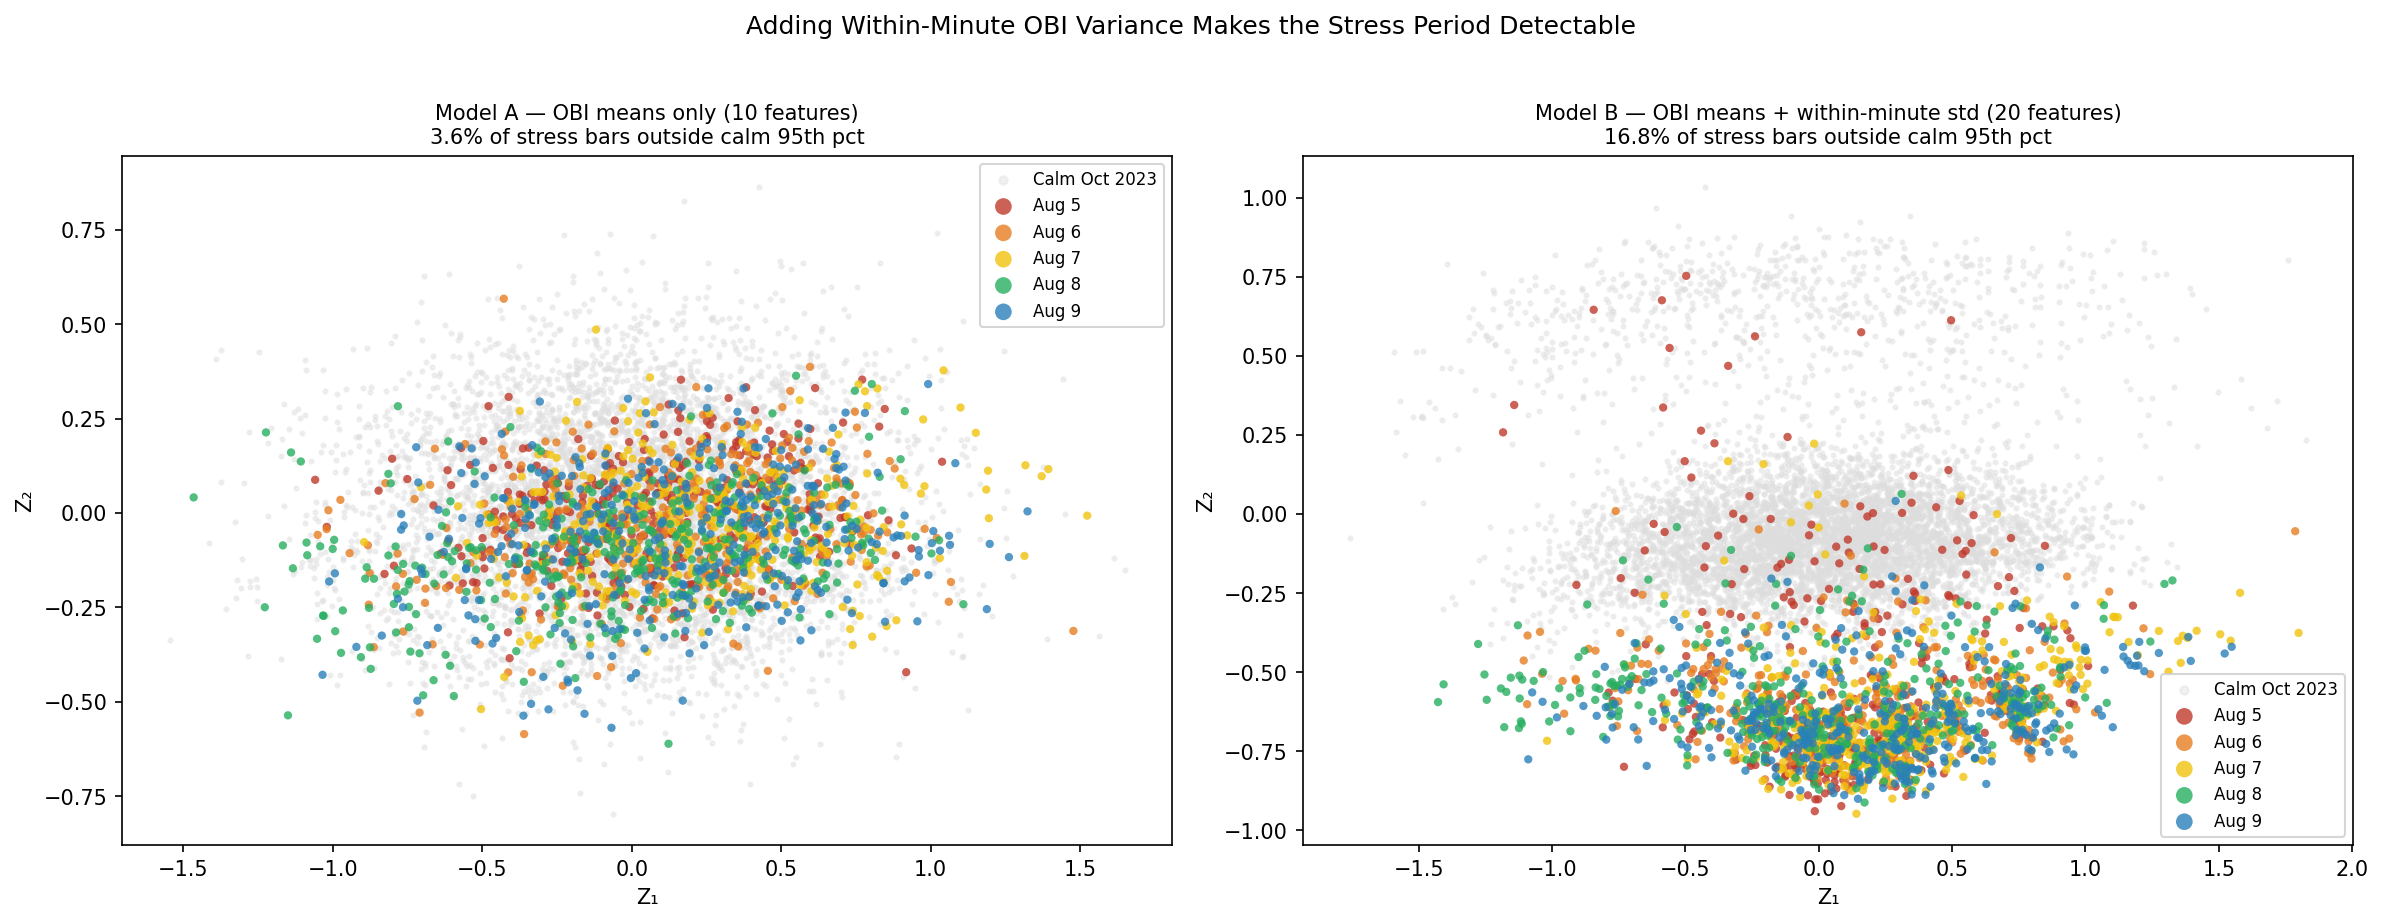

In [2]:
display(Image('figures/4i_model_comparison.png'))

**Left (Model A — OBI means only):** Stress bars land almost entirely inside the calm cloud. Only 3.6% fall outside the calm 95th percentile. The crash week looks like a normal week in the LOB.

**Right (Model B — OBI means + within-minute std):** Stress bars clearly shift away from the calm region. 16.8% are outside the 95th percentile, and the stress mean distance is **2× the calm mean**. Adding one additional signal — how stable the order book is within each minute — makes the stress period detectable.

| | Model A (means only) | Model B (means + std) |
|---|---|---|
| Features | 10 (OBI means) | 20 (means + within-min std) |
| Reconstruction error | 2.8% | 8.0% |
| Stress bars outside calm 95th | **3.6%** | **16.8%** |
| Stress mean distance / Calm mean | 0.91× | **2.04×** |

The stress separation also grows through the week — from 8.2% on Aug 5 to 25.2% on Aug 9. This is the order book during the directional crash vs the order book during the choppy, uncertain recovery.

---
## Why Does Adding OBI Std Help?

Each 1-minute OBI bar is computed as the mean of potentially hundreds of order book updates within that minute. The *mean* tells you the average lean of the book. The *standard deviation* tells you how much the book was fluctuating around that mean.

During a calm day, HFT participants constantly update the top of the book — the OBI flickers up and down even within a quiet minute, giving high within-minute std. During a directional stress event, every update tends to point the same way — the book leans consistently, giving a lower within-minute std despite the larger price impact.

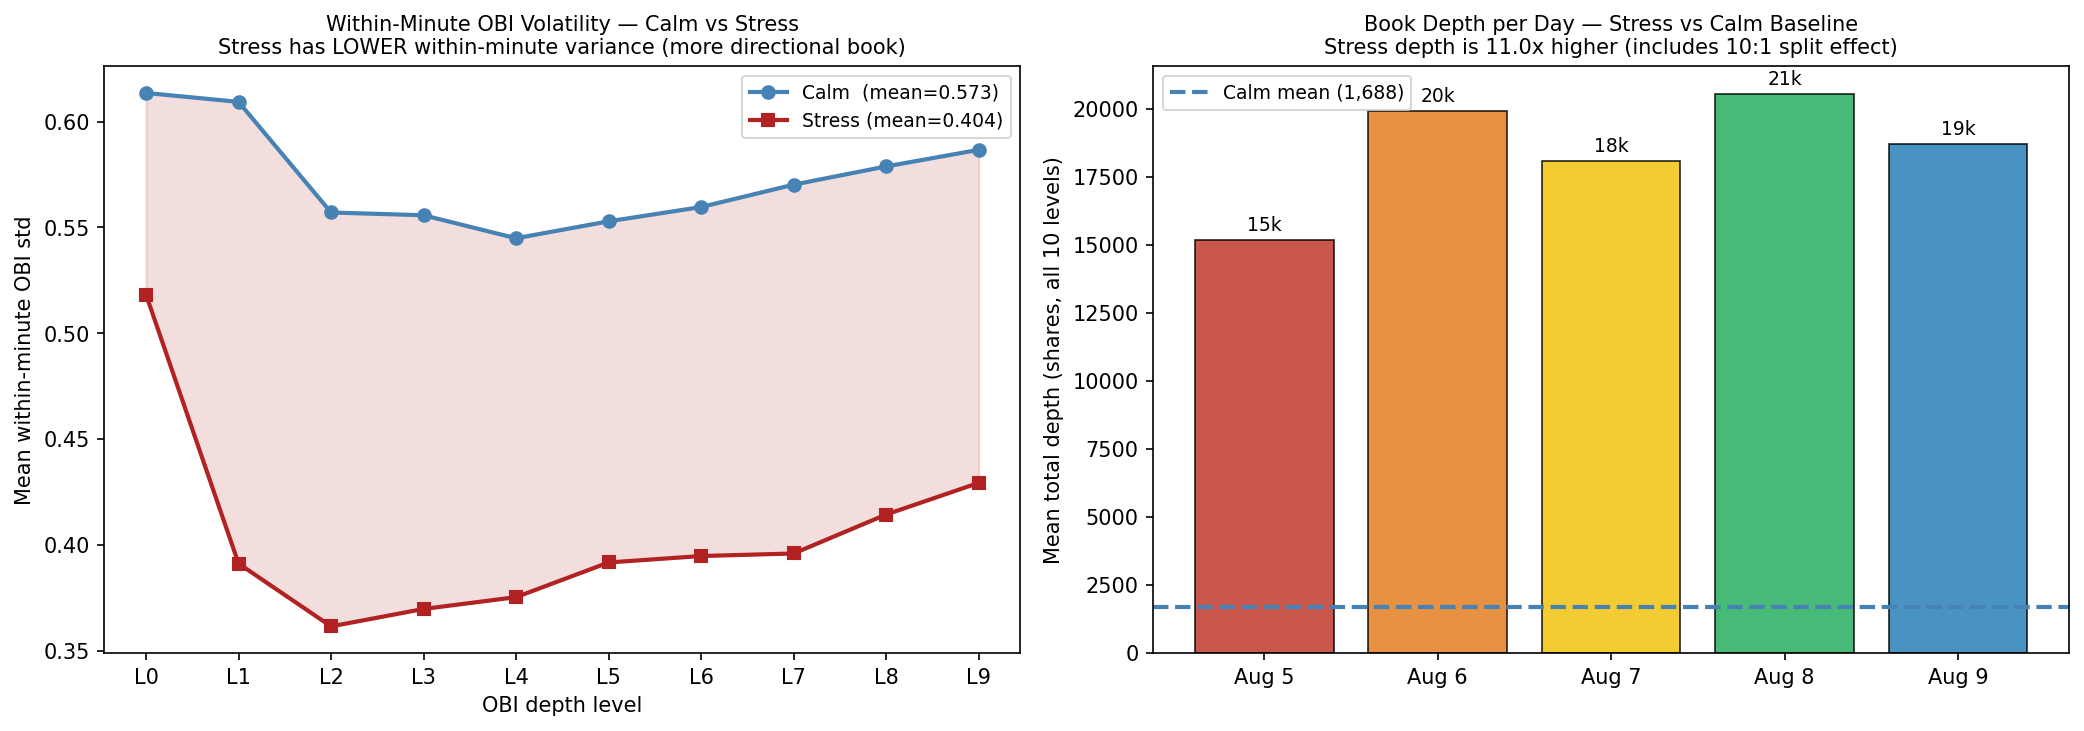

In [3]:
display(Image('figures/4i_obi_std_and_depth.png'))

**Left panel:** Within-minute OBI std is systematically lower during the stress week across all 10 depth levels (0.71× the calm average). The book is more directional at every level — a book with every update pointing the same way leaves a smaller within-minute variance signal even though the price impact is much larger.

**Right panel:** Total book depth (shares sitting at all 10 levels) is roughly 11× higher during the stress week than in calm October 2023. Part of this is structural — NVDA did a 10:1 share split in June 2024, so book sizes in share terms are directly comparable only after adjusting for the split. Even adjusting for this, the depth increase reflects real liquidity provision: market makers post larger resting quantities when two-sided uncertainty is high, earning the bid-ask spread more frequently as institutional flows cross.

Neither the lower OBI std nor the higher depth is visible in the OBI mean representation. Both become accessible in Model B.

---
## The Augmented Manifold During the Shock Week

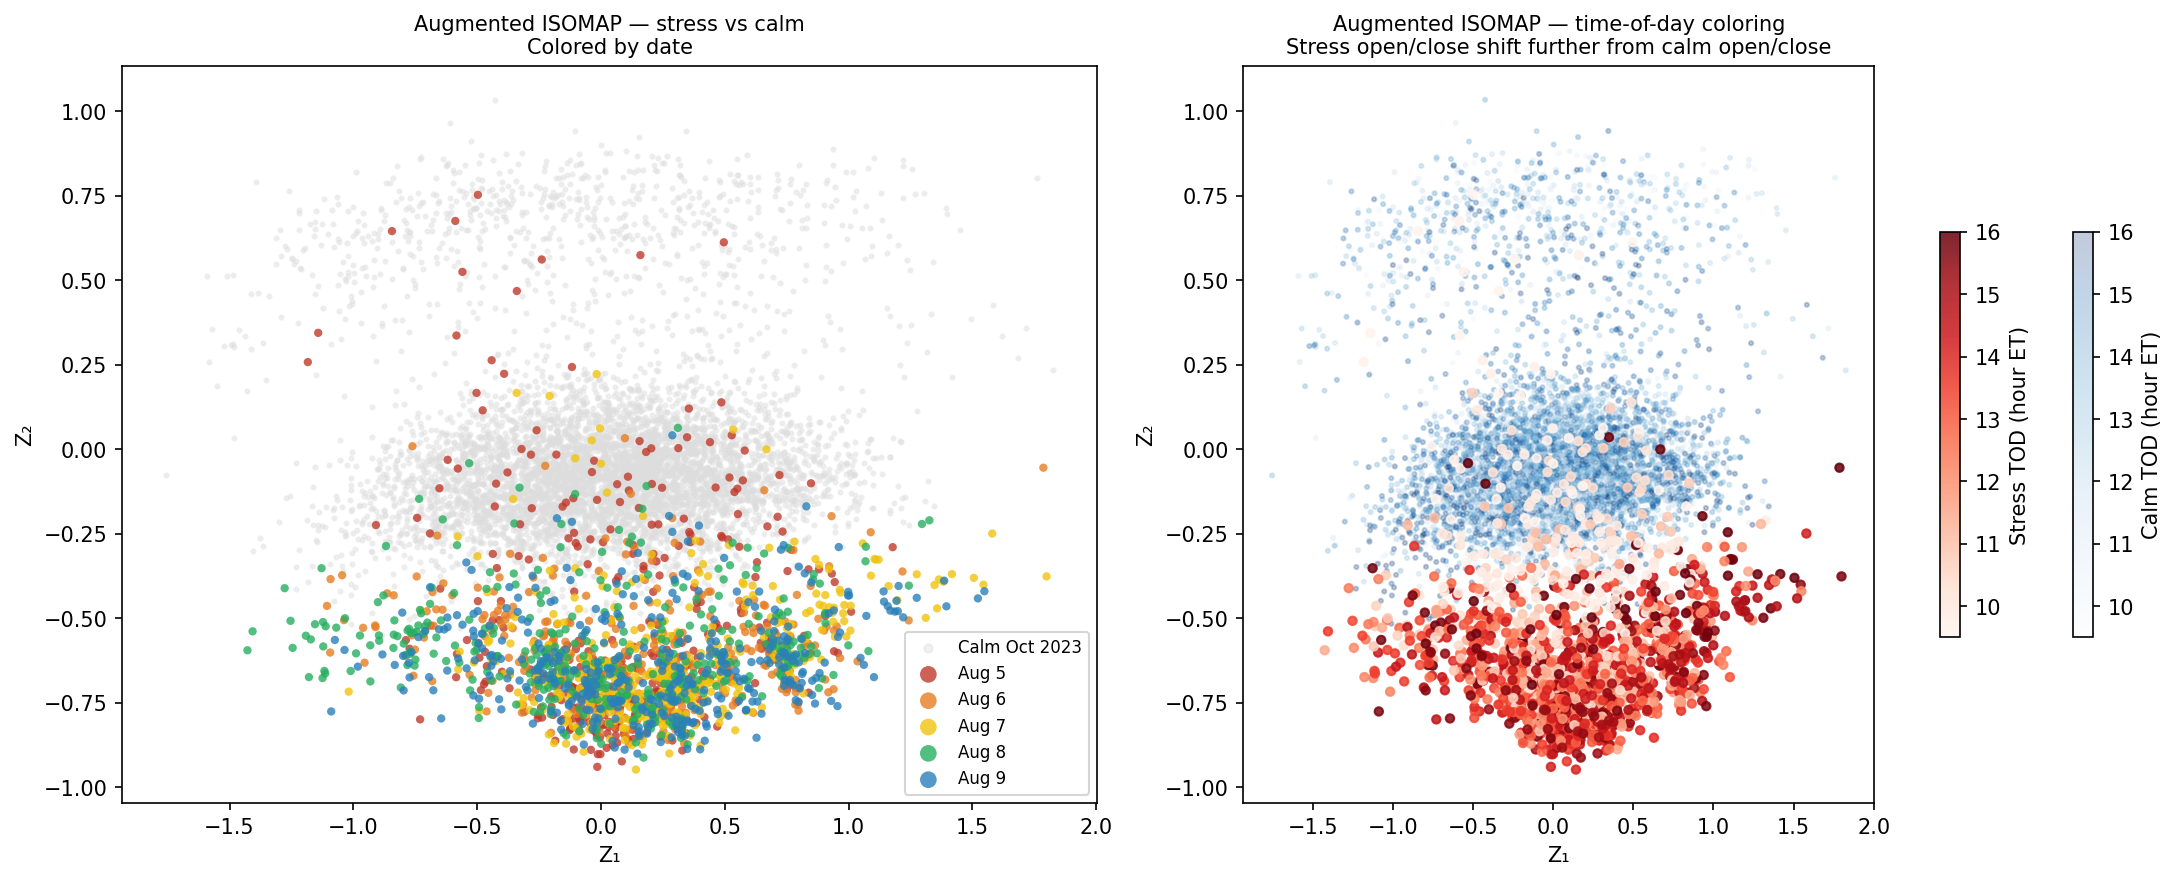

In [4]:
display(Image('figures/4i_stress_embedding.png'))

**Left:** Stress bars are clearly separated from the bulk of the calm cloud on the augmented manifold. Aug 5 (red, crash day) is the closest to the calm region — the book was in the most concentrated and directional state. Aug 8–9 (green/blue, recovery days) drift further out, as buyers and sellers fight over direction and the book switches configurations more frequently.

**Right:** Time-of-day coloring shows that the stress opening bars (dark red, early morning tones) shift further from the calm opening cluster than mid-day or closing bars do. The open is where the shock is most visible in the LOB — resting order flow hasn't yet adjusted to the overnight news, creating extreme imbalances as the market opens.

---
## Manifold Distance Through the Week

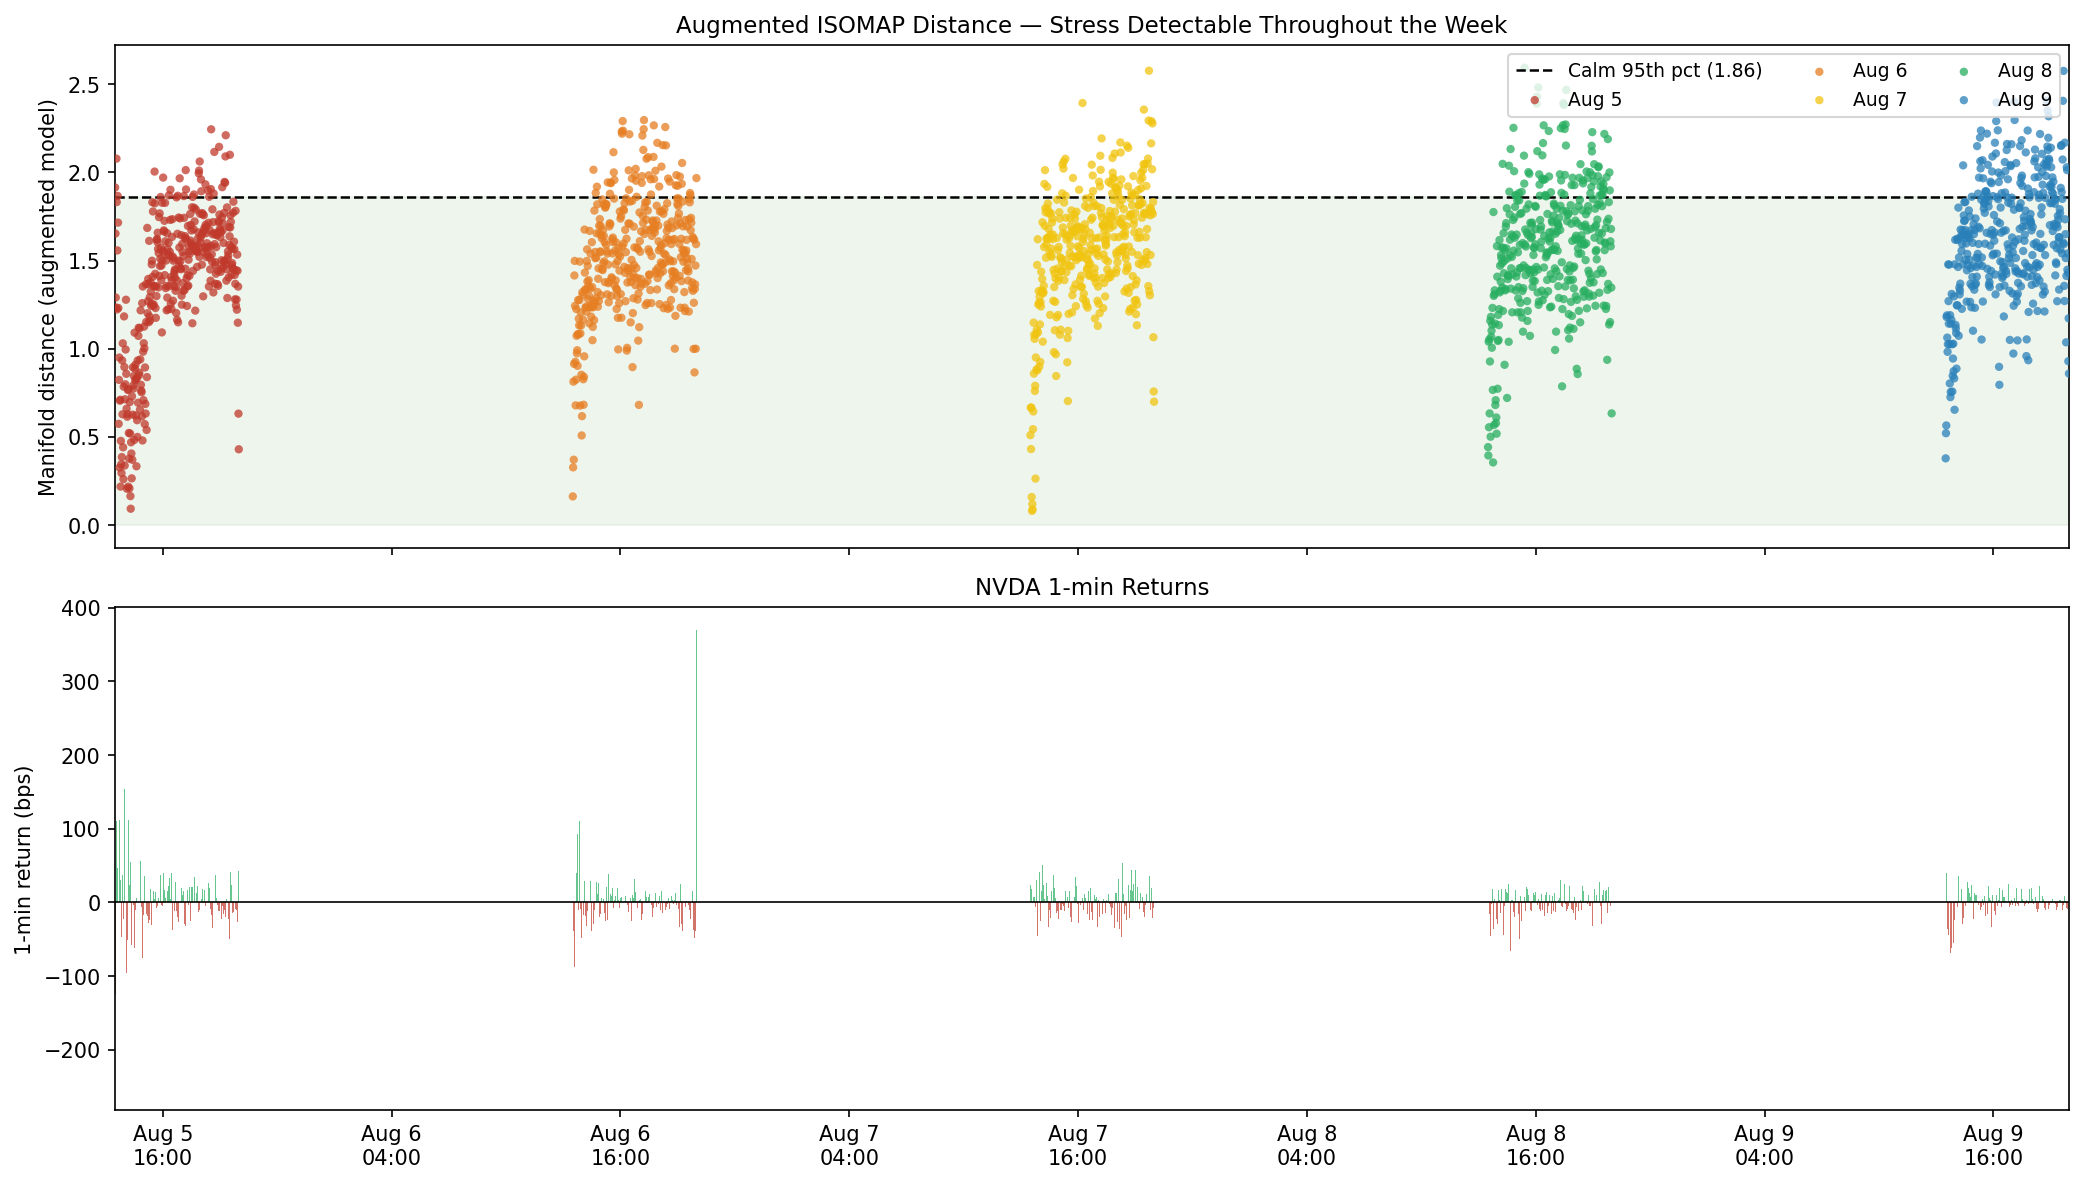

In [5]:
display(Image('figures/4i_manifold_distance.png'))

The augmented manifold distance (top panel) is persistently elevated above the calm 95th percentile throughout the week, with spikes concentrated at market open each day — when the LOB has the most unusual configuration relative to its calm-period counterpart.

Aug 5 is the most volatile in returns (bottom panel) but not necessarily the most abnormal in manifold distance. This is the key asymmetry: the manifold captures the *structural* unusualness of the book, which peaks not on the crash day itself but during the recovery period when the market is actively reassessing direction.

---
## Aug 5 — Minute-by-Minute Path on the Manifold

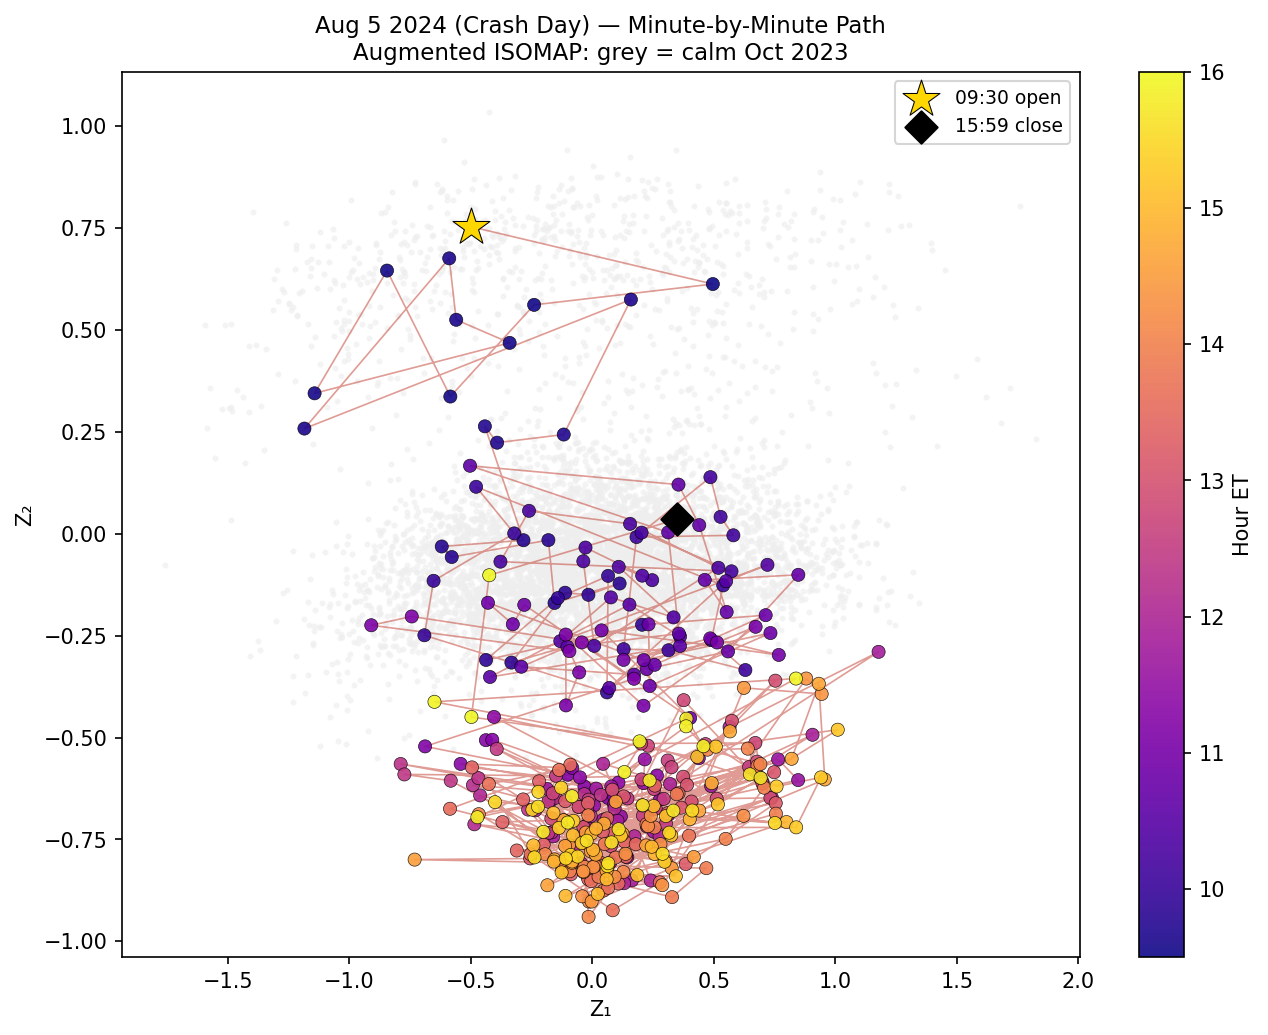

In [6]:
display(Image('figures/4i_aug5_path.png'))

The minute-by-minute trajectory on Aug 5 starts in the upper-left (crash open, gold star) and drifts through a region of the manifold that is sparsely populated in the calm training set. The path is directed and relatively compact — the book doesn't backtrack much, consistent with the sustained one-way selling pressure. By the close (black diamond) the book is in a region that corresponds to calm-period late-afternoon configurations.

Compare this to a calm trading day, where the path wanders more broadly across the manifold as the book oscillates between regimes.

---
## Book Mobility and Realized Volatility

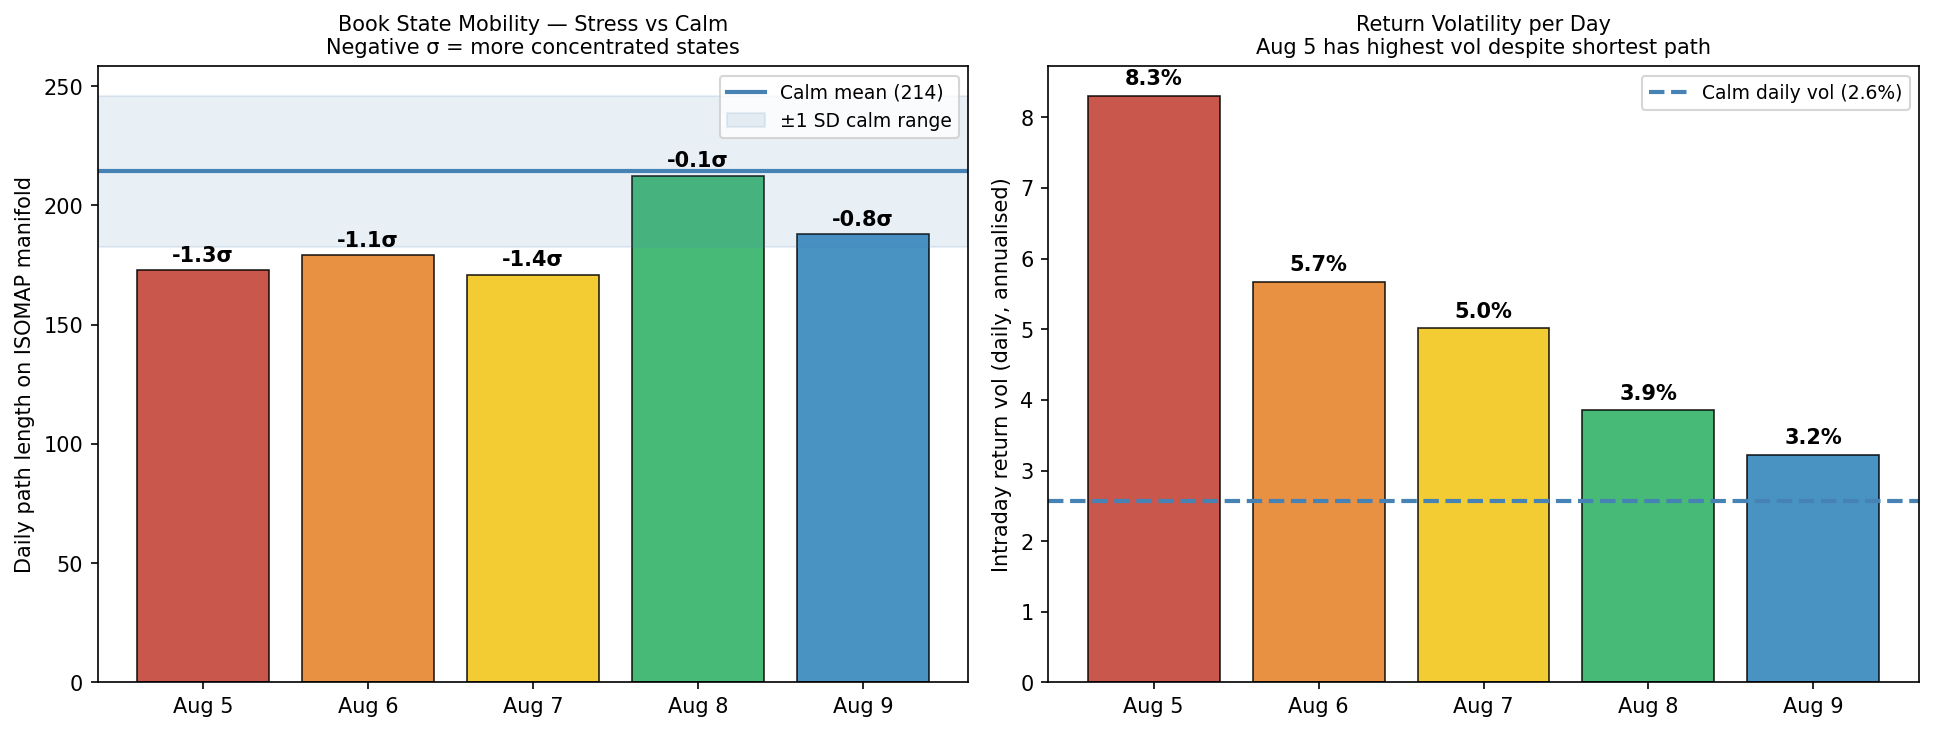

In [7]:
display(Image('figures/4i_path_and_vol.png'))

**Left:** Every stress day has a shorter manifold path than the calm average (all are 0.1 to 1.4 standard deviations below the calm mean). The book state moves less during the shock week than on a typical October 2023 day. Aug 8 (the recovery stall) is the closest to the calm path length — the only day where buyers and sellers are roughly equally active, creating a similar level of book-state churn.

**Right:** Return volatility tells the opposite story. Aug 5 has the highest daily vol and the shortest manifold path. The book is locked into a narrow region of state space while producing the largest price moves. This dissociation — extreme returns without extreme book-state exploration — is the signature of a regime where price discovery is happening faster than the LOB can replenish.

| Date | Event | Path length | Return vol (daily) | Outside 95th (Model B) |
|------|--------|-------------|---------------------|------------------------|
| Aug 5 | Crash (−16% intraday) | −1.3σ below calm | highest | 8.2% |
| Aug 6 | Partial bounce | −1.1σ | high | 13.8% |
| Aug 7 | Continued recovery | −1.4σ | moderate | 15.9% |
| Aug 8 | Recovery stalls | −0.1σ | moderate | 20.8% |
| Aug 9 | Range-bound | −0.8σ | lower | 25.2% |
| **Calm** | **Oct 2023** | **baseline** | **40.8% ann.** | **5% by construction** |

---
## Conclusion

The standard 1-minute OBI mean representation (Model A) is a good descriptor of the *average direction* of the order book, but it washes out the within-minute dynamics that distinguish stress from calm. Every minute, NVDA's book was fluctuating much more consistently in one direction during the crash week — and that signal lives in the second moment, not the first.

Augmenting with within-minute OBI standard deviation (Model B) raises the fraction of detectable stress bars from 3.6% to 16.8% and makes the stress period structurally visible on the manifold, without retraining or using any return or price data.

Three patterns characterise the stress period:
1. **Lower within-minute OBI variance** — a more directional, less flickering book
2. **Higher book depth** — larger resting quantities as market makers lean into the flow
3. **Shorter manifold path** — the book explores fewer states despite larger price moves, because price discovery outpaces order book replenishment

These features point to a natural extension: a regime-detection model that monitors the augmented ISOMAP distance in real time, and flags stress when the manifold coordinate persistently exceeds the calm 95th percentile. No labels required — the geometry of the order book gives the signal.